<a href="https://colab.research.google.com/github/vpagonis/Python-Codes/blob/main/AncientTL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Figure2**

---------------------------- CODE OUTPUT -----------------------------
Using LS starting values: a=0.233, b=0.016, c=0.096

Metropolis-Hastings:
  a = 0.233 ± 0.009 (95% CI: [0.214,      0.252])
  b = 0.016 ± 0.001 (95% CI: [0.013,      0.019])
  c = 0.096 ± 0.004 (95% CI: [0.088,       0.105])
  sigma = 0.008


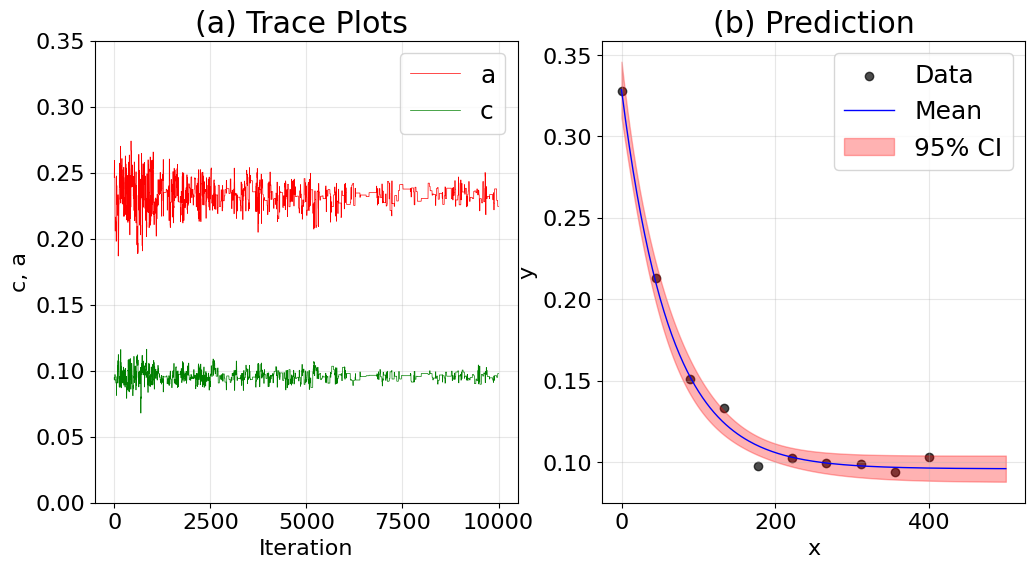


Effective Sample Size (ESS):
  a: 58 (out of 10000 samples)
  b: 45 (out of 10000 samples)
  c: 55 (out of 10000 samples)

COVARIANCE MATRIX

Covariance between parameters:
              a         b         c     sigma
a      0.000079  0.000001 -0.000012  0.000001
b      0.000001  0.000002  0.000004  0.000000
c     -0.000012  0.000004  0.000016  0.000000
sigma  0.000001  0.000000  0.000000  0.000008

PARAMETER UNCERTAINTY ANALYSIS

Parameter uncertainties (standard deviations):
  a: ±0.008894
  b: ±0.001483
  c: ±0.003991
  σ: ±0.002902


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize
import pandas as pd

import statsmodels.api as sm

print('-'*28,'CODE OUTPUT','-'*29)
rng = np.random.default_rng(seed=122)

plt.rcParams["font.size"] = 16

def model(x, a, b, c):
    """Negative exponential model: y = a * exp(-b * x) + c"""
    return a * np.exp(-b * x) + c

def log_prior(a, b, c, sigma):
    # log prior for all parameters
    # Parameter constraints
    if c <= 0:
        return -np.inf  # Reject negative sigma
    if sigma <= 0:
        return -np.inf  # Reject negative sigma

    #  Add positivity for a and b if desired
    # if a <= 0 or b <= 0:
    #     return -np.inf

    #  Broad normal priors for all parameters
    log_prior_a = -0.5 * (a / 100) ** 2         # N(0, 100²)
    log_prior_b = -0.5 * (b / 1) ** 2           # N(0, 1²)
    log_prior_c = -0.5 * (c / 100) ** 2         # N(0, 100²)
    log_prior_sigma = -0.5 * (sigma / 10) ** 2  # HalfN(0, 10²)

    return log_prior_a + log_prior_b + log_prior_c + log_prior_sigma

def log_likelihood(y, y_pred, sigma):
    """Log likelihood assuming Gaussian errors"""
    return -0.5 * np.sum(((y - y_pred) / sigma) ** 2) - len(y) * np.log(sigma)

def log_posterior(params, x, y):
    """Log posterior probability"""
    a, b, c, sigma = params
    y_pred = model(x, a, b, c)
    lp = log_prior(a, b, c, sigma)
    return lp + log_likelihood(y, y_pred, sigma)

def metropolis(x, y, initial_params=None, n_steps=40000, burn_in=3000):
    """Metropolis-Hastings algorithm for negative exponential fitting"""

    # Use least squares to find good starting values
    popt, pcov = optimize.curve_fit(model, x, y,
                        p0=[np.max(y)-np.min(y), 0.01, np.min(y)],
                        bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]))
    a, b, c = popt
    print(f"Using LS starting values: a={a:.3f}, b={b:.3f}, c={c:.3f}")

    sigma = np.std(y - model(x, a, b, c))

    samples = []

    # Step sizes based on least squares uncertainties if available
    step_a, step_b, step_c = 0.02, 0.002, 0.01

    step_sigma = 0.05 * sigma

    current_params = np.array([a, b, c, sigma])
    current_log_post = log_posterior(current_params, x, y)

    for i in range(n_steps):
        # Propose new parameters
        new_params = current_params + rng.normal(0, [step_a, step_b,\
                                                    step_c, step_sigma])

        # Compute log-posterior for new parameters
        new_log_post = log_posterior(new_params, x, y)

        # Acceptance probability
        log_alpha = new_log_post - current_log_post

        if np.log(rng.random()) < log_alpha:
            current_params = new_params
            current_log_post = new_log_post

        samples.append(current_params.copy())

    # Discard burn-in and return samples
    return np.array(samples[burn_in:]), np.array(samples)

# --- Load data from a URL

x_data = np.linspace(0,400,10)
y = 0.3*np.exp(-.02*x_data)+0.1
y_data = [y[i]*(1+rng.normal(0,.1)) for i in range(len(y))]

# Run MCMC
samples, full_samples = metropolis(x_data, y_data, n_steps=40000,   burn_in=30000)

# Extract parameter samples
a_samples = samples[:, 0]
b_samples = samples[:, 1]
c_samples = samples[:, 2]
sigma_samples = samples[:, 3]

# Get posterior statistics
a_est, a_std = np.mean(a_samples), np.std(a_samples)
b_est, b_std = np.mean(b_samples), np.std(b_samples)
c_est, c_std = np.mean(c_samples), np.std(c_samples)
sigma_est = np.mean(sigma_samples)

a_ci = np.percentile(a_samples, [2.5, 97.5])
b_ci = np.percentile(b_samples, [2.5, 97.5])
c_ci = np.percentile(c_samples, [2.5, 97.5])


print("\nMetropolis-Hastings:")
print(f"  a = {a_est:.3f} ± {a_std:.3f} (95% CI: [{a_ci[0]:.3f},\
      {a_ci[1]:.3f}])")
print(f"  b = {b_est:.3f} ± {b_std:.3f} (95% CI: [{b_ci[0]:.3f},\
      {b_ci[1]:.3f}])")
print(f"  c = {c_est:.3f} ± {c_std:.3f} (95% CI: [{c_ci[0]:.3f}, \
      {c_ci[1]:.3f}])")
print(f"  sigma = {sigma_est:.3f}")

# Calculate fit quality metrics
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    r_squared = 1 - np.sum(residuals**2) / np.sum((y_true - \
                   np.mean(y_true))**2)
    rmse = np.sqrt(np.mean(residuals**2))
    return r_squared, rmse

# Predictions
y_pred_mh = model(x_data, a_est, b_est, c_est)

r2_mh, rmse_mh = calculate_metrics(y_data, y_pred_mh)


# Create figure for ACF plots
fig_acf, axes = plt.subplots(1,2, figsize=(12, 6))

plt.rcParams["font.size"] = 18
# Trace plot  for b
axes[0].plot(a_samples, linewidth=0.5, color='red',label='a')
axes[0].plot(c_samples, linewidth=0.5, color='green',label='c')
axes[0].set_ylabel('c, a')
axes[0].set_xlabel('Iteration')
axes[0].set_title('(a) Trace Plots ')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0,.35)
# plt.show()

# Prediction intervals from Metropolis
x_fine = np.linspace(0, 500, 200)
n_predict = 1000
predictions = np.zeros((len(x_fine), n_predict))

for i in range(n_predict):
    idx = rng.integers(0, len(samples))
    a_sample, b_sample, c_sample, _ = samples[idx]
    predictions[:, i] = model(x_fine, a_sample, b_sample, c_sample)

pred_mean = np.mean(predictions, axis=1)
pred_std = np.std(predictions, axis=1)

axes[1].scatter(x_data, y_data, alpha=0.7, label='Data', color='black');
axes[1].plot(x_fine, pred_mean, 'b-', linewidth=1, label='Mean');
axes[1].fill_between(x_fine, pred_mean - 2*pred_std, pred_mean + 2*pred_std,
                 alpha=0.3, color='red', label='95% CI');

axes[1].set_xlabel('x');
axes[1].set_ylabel('y');
axes[1].legend();
axes[1].grid(True, alpha=0.3)
axes[1].set_title('(b) Prediction');
plt.show()

# Calculate and print effective sample size (ESS)
def effective_sample_size(samples):
    """Calculate effective sample size using statsmodels"""
    n = len(samples)
    acf = sm.tsa.stattools.acf(samples, nlags=n-1, fft=False)
    # Find first lag where acf becomes negative or crosses zero
    rho = acf[1:]
    # Sum positive autocorrelations
    ess = n / (1 + 2 * np.sum(rho[rho > 0]))
    return ess

ess_a = effective_sample_size(a_samples)
ess_b = effective_sample_size(b_samples)
ess_c = effective_sample_size(c_samples)

print("\nEffective Sample Size (ESS):")
print(f"  a: {ess_a:.0f} (out of {len(a_samples)} samples)")
print(f"  b: {ess_b:.0f} (out of {len(b_samples)} samples)")
print(f"  c: {ess_c:.0f} (out of {len(c_samples)} samples)")



# Calculate and print covariance matrix
cov_matrix = np.cov([a_samples, b_samples, c_samples, sigma_samples])
print("\n" + "="*50)
print("COVARIANCE MATRIX")
print("="*50)
print("\nCovariance between parameters:")
cov_df = pd.DataFrame(cov_matrix,
                      index=['a', 'b', 'c', 'sigma'],
                      columns=['a', 'b', 'c', 'sigma'])
print(cov_df.round(6))

# Parameter uncertainty analysis
print("\n" + "="*50)
print("PARAMETER UNCERTAINTY ANALYSIS")
print("="*50)
print("\nParameter uncertainties (standard deviations):")
print(f"  a: ±{a_std:.6f}")
print(f"  b: ±{b_std:.6f}")
print(f"  c: ±{c_std:.6f}")
print(f"  σ: ±{np.std(sigma_samples):.6f}")


# **Figures 3 and 4**

---------------------------- CODE OUTPUT -----------------------------
Using LS starting values: a=0.233, b=0.016, c=0.096

Metropolis-Hastings:
  a = 0.233 ± 0.010 (95% CI: [0.211,      0.253])
  b = 0.016 ± 0.002 (95% CI: [0.013,      0.020])
  c = 0.096 ± 0.005 (95% CI: [0.086,       0.106])
  sigma = 0.009

Fit Quality Metrics:
Metropolis:     R² = 0.9940, RMSE = 0.0055


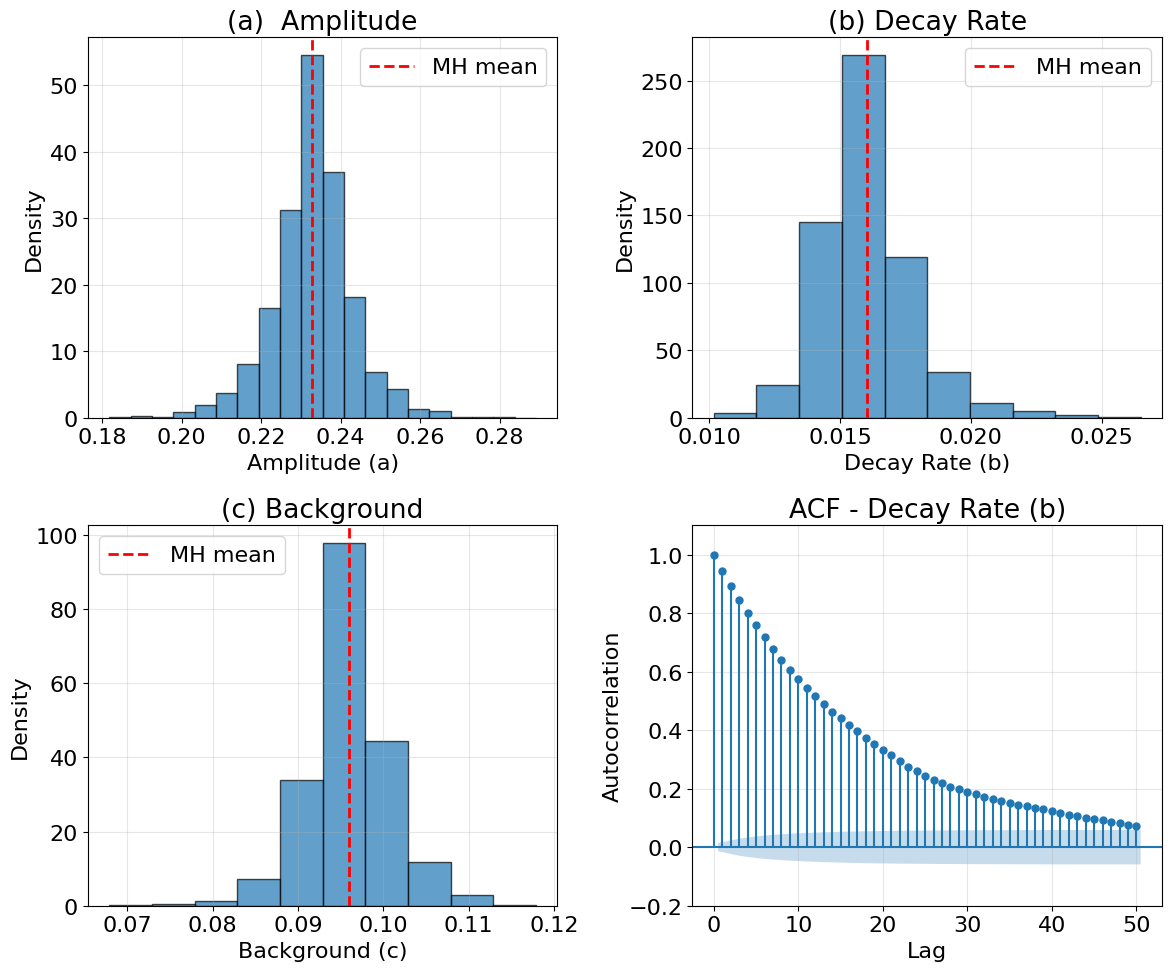


Effective Sample Size (ESS):
  a: 98 (out of 20000 samples)
  b: 68 (out of 20000 samples)
  c: 84 (out of 20000 samples)

PARAMETER CORRELATION MATRIX

Correlation coefficients between parameters:
           a      b      c  sigma
a      1.000  0.055 -0.365 -0.016
b      0.055  1.000  0.658  0.157
c     -0.365  0.658  1.000  0.058
sigma -0.016  0.157  0.058  1.000

--------------------------------------------------
Strong correlations (|r| > 0.5):
  • b - c: 0.658

COVARIANCE MATRIX

Covariance between parameters:
              a         b         c     sigma
a      0.000101  0.000001 -0.000018 -0.000001
b      0.000001  0.000003  0.000006  0.000001
c     -0.000018  0.000006  0.000024  0.000001
sigma -0.000001  0.000001  0.000001  0.000012

PARAMETER UNCERTAINTY ANALYSIS

Parameter uncertainties (standard deviations):
  a: ±0.010035
  b: ±0.001765
  c: ±0.004874
  σ: ±0.003397

Correlation-based degrees of freedom penalty: 0.900


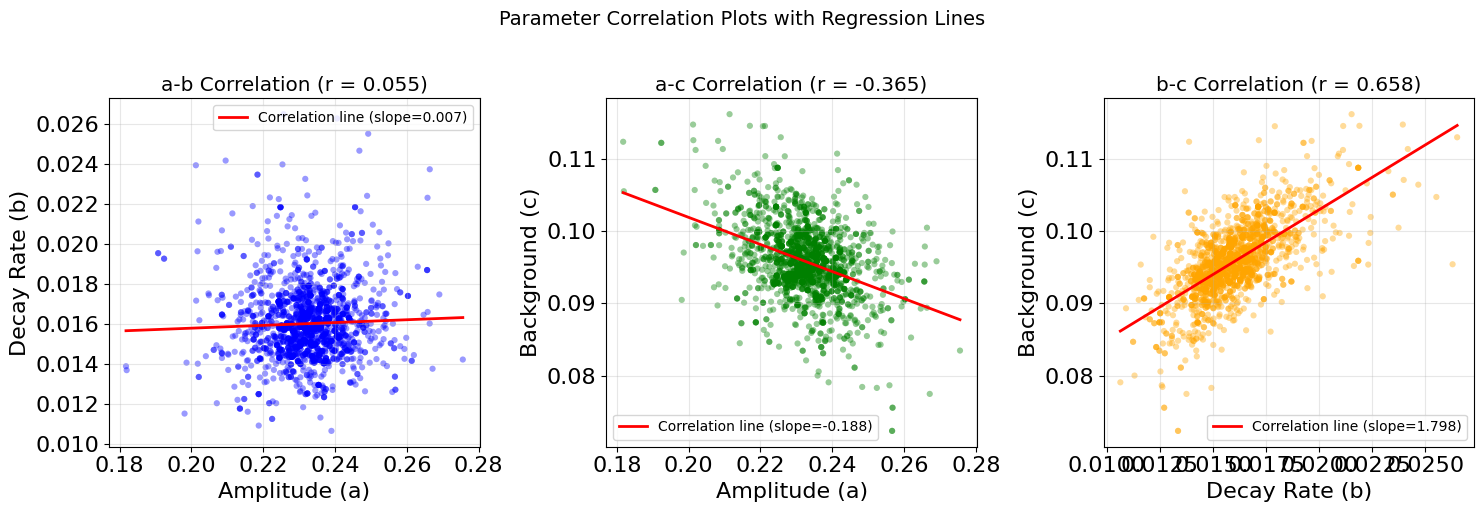

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
print('-'*28,'CODE OUTPUT','-'*29)
rng = np.random.default_rng(seed=122)

plt.rcParams["font.size"] = 16

def model(x, a, b, c):
    """Negative exponential model: y = a * exp(-b * x) + c"""
    return a * np.exp(-b * x) + c

def log_prior(a, b, c, sigma):
    # log prior for all parameters
    # Parameter constraints
    if c <= 0:
        return -np.inf  # Reject negative sigma
    if sigma <= 0:
        return -np.inf  # Reject negative sigma

    #  Add positivity for a and b if desired
    # if a <= 0 or b <= 0:
    #     return -np.inf

    #  Broad normal priors for all parameters
    log_prior_a = -0.5 * (a / 100) ** 2         # N(0, 100²)
    log_prior_b = -0.5 * (b / 1) ** 2           # N(0, 1²)
    log_prior_c = -0.5 * (c / 100) ** 2         # N(0, 100²)
    log_prior_sigma = -0.5 * (sigma / 10) ** 2  # HalfN(0, 10²)

    return log_prior_a + log_prior_b + log_prior_c + log_prior_sigma

def log_likelihood(y, y_pred, sigma):
    """Log likelihood assuming Gaussian errors"""
    return -0.5 * np.sum(((y - y_pred) / sigma) ** 2) - len(y) * np.log(sigma)

def log_posterior(params, x, y):
    """Log posterior probability"""
    a, b, c, sigma = params
    y_pred = model(x, a, b, c)
    lp = log_prior(a, b, c, sigma)
    return lp + log_likelihood(y, y_pred, sigma)

def metropolis(x, y, initial_params=None, n_steps=40000, burn_in=3000):
    """Metropolis-Hastings algorithm for negative exponential fitting"""

    # Use least squares to find good starting values
    popt, pcov = optimize.curve_fit(model, x, y,
                        p0=[np.max(y)-np.min(y), 0.01, np.min(y)],
                        bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]))
    a, b, c = popt
    print(f"Using LS starting values: a={a:.3f}, b={b:.3f}, c={c:.3f}")

    sigma = np.std(y - model(x, a, b, c))

    samples = []

    # Step sizes based on least squares uncertainties if available
    step_a, step_b, step_c = 0.02, 0.002, 0.01

    step_sigma = 0.05 * sigma

    current_params = np.array([a, b, c, sigma])
    current_log_post = log_posterior(current_params, x, y)

    for i in range(n_steps):
        # Propose new parameters
        new_params = current_params + rng.normal(0, [step_a, step_b,\
                                                    step_c, step_sigma])

        # Compute log-posterior for new parameters
        new_log_post = log_posterior(new_params, x, y)

        # Acceptance probability
        log_alpha = new_log_post - current_log_post

        if np.log(rng.random()) < log_alpha:
            current_params = new_params
            current_log_post = new_log_post

        samples.append(current_params.copy())

    # Discard burn-in and return samples
    return np.array(samples[burn_in:])

# --- Load data from a URL

x_data = np.linspace(0,400,10)
y = 0.3*np.exp(-.02*x_data)+0.1
y_data = [y[i]*(1+rng.normal(0,.1)) for i in range(len(y))]

# Run MCMC
samples = metropolis(x_data, y_data, n_steps=40000,   burn_in=20000)

# Extract parameter samples
a_samples = samples[:, 0]
b_samples = samples[:, 1]
c_samples = samples[:, 2]
sigma_samples = samples[:, 3]

# Get posterior statistics
a_est, a_std = np.mean(a_samples), np.std(a_samples)
b_est, b_std = np.mean(b_samples), np.std(b_samples)
c_est, c_std = np.mean(c_samples), np.std(c_samples)
sigma_est = np.mean(sigma_samples)

a_ci = np.percentile(a_samples, [2.5, 97.5])
b_ci = np.percentile(b_samples, [2.5, 97.5])
c_ci = np.percentile(c_samples, [2.5, 97.5])


print("\nMetropolis-Hastings:")
print(f"  a = {a_est:.3f} ± {a_std:.3f} (95% CI: [{a_ci[0]:.3f},\
      {a_ci[1]:.3f}])")
print(f"  b = {b_est:.3f} ± {b_std:.3f} (95% CI: [{b_ci[0]:.3f},\
      {b_ci[1]:.3f}])")
print(f"  c = {c_est:.3f} ± {c_std:.3f} (95% CI: [{c_ci[0]:.3f}, \
      {c_ci[1]:.3f}])")
print(f"  sigma = {sigma_est:.3f}")

# Calculate fit quality metrics
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    r_squared = 1 - np.sum(residuals**2) / np.sum((y_true - \
                   np.mean(y_true))**2)
    rmse = np.sqrt(np.mean(residuals**2))
    return r_squared, rmse

# Predictions
y_pred_mh = model(x_data, a_est, b_est, c_est)

r2_mh, rmse_mh = calculate_metrics(y_data, y_pred_mh)

print("\nFit Quality Metrics:")
print(f"Metropolis:     R² = {r2_mh:.4f}, RMSE = {rmse_mh:.4f}")

plt.figure(figsize=(12, 10))

plt.rcParams["font.size"] = 16
# Data and all fitted models
plt.subplot(2,2, 1)
plt.hist(a_samples, bins=20, alpha=0.7, density=True, edgecolor='black')
plt.axvline(a_est, color='red', linestyle='--', linewidth=2, label='MH mean')
plt.xlabel('Amplitude (a)'); plt.ylabel('Density');plt.legend()
plt.title('(a)  Amplitude')
plt.grid(True, alpha=0.3)

# Parameter distributions from Metropolis
plt.subplot(2,2, 2)
plt.hist(b_samples, bins=10, alpha=0.7, density=True, edgecolor='black')
plt.axvline(b_est, color='red', linestyle='--', linewidth=2, label='MH mean')
plt.xlabel('Decay Rate (b)'); plt.ylabel('Density')
plt.legend();plt.grid(True, alpha=0.3)
plt.title('(b) Decay Rate')


plt.subplot(2,2, 3)
plt.hist(c_samples, bins=10, alpha=0.7, density=True, edgecolor='black')
plt.axvline(c_est, color='red', linestyle='--', linewidth=2, label='MH mean')
plt.xlabel('Background (c)'); plt.ylabel('Density')
plt.legend();plt.grid(True, alpha=0.3)
plt.title('(c) Background')

# Convergence diagnostics
plt.subplot(2,2, 4)
# ACF for b
ax = plt.gca()  # Get current axes
plot_acf(b_samples, lags=50, ax=ax, alpha=0.05)
plt.title('ACF - Decay Rate (b)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True, alpha=0.3)

plt.ylim(-.2,1.1)

plt.tight_layout();
plt.show()

# Calculate and print effective sample size (ESS)
def effective_sample_size(samples):
    """Calculate effective sample size using statsmodels"""
    n = len(samples)
    acf = sm.tsa.stattools.acf(samples, nlags=n-1, fft=False)
    # Find first lag where acf becomes negative or crosses zero
    rho = acf[1:]
    # Sum positive autocorrelations
    ess = n / (1 + 2 * np.sum(rho[rho > 0]))
    return ess

ess_a = effective_sample_size(a_samples)
ess_b = effective_sample_size(b_samples)
ess_c = effective_sample_size(c_samples)

print("\nEffective Sample Size (ESS):")
print(f"  a: {ess_a:.0f} (out of {len(a_samples)} samples)")
print(f"  b: {ess_b:.0f} (out of {len(b_samples)} samples)")
print(f"  c: {ess_c:.0f} (out of {len(c_samples)} samples)")

# Add correlation plots and correlation matrix
import seaborn as sns

# Create correlation matrix of parameters
params_df = pd.DataFrame({
    'a': a_samples,
    'b': b_samples,
    'c': c_samples,
    'sigma': sigma_samples
})

# Calculate correlation matrix
corr_matrix = params_df.corr()

# Print correlation matrix with nice formatting
print("\n" + "="*50)
print("PARAMETER CORRELATION MATRIX")
print("="*50)
print("\nCorrelation coefficients between parameters:")
print(corr_matrix.round(3))

# Identify strong correlations
print("\n" + "-"*50)
print("Strong correlations (|r| > 0.5):")
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            strong_corr.append(f"{corr_matrix.index[i]} - {corr_matrix.columns[j]}: {corr_val:.3f}")

if strong_corr:
    for corr in strong_corr:
        print(f"  • {corr}")
else:
    print("  No strong correlations found")

# Calculate and print covariance matrix
cov_matrix = np.cov([a_samples, b_samples, c_samples, sigma_samples])
print("\n" + "="*50)
print("COVARIANCE MATRIX")
print("="*50)
print("\nCovariance between parameters:")
cov_df = pd.DataFrame(cov_matrix,
                      index=['a', 'b', 'c', 'sigma'],
                      columns=['a', 'b', 'c', 'sigma'])
print(cov_df.round(6))

# Parameter uncertainty analysis
print("\n" + "="*50)
print("PARAMETER UNCERTAINTY ANALYSIS")
print("="*50)
print("\nParameter uncertainties (standard deviations):")
print(f"  a: ±{a_std:.6f}")
print(f"  b: ±{b_std:.6f}")
print(f"  c: ±{c_std:.6f}")
print(f"  σ: ±{np.std(sigma_samples):.6f}")

# Correlation-based effective degrees of freedom
total_variance = np.trace(cov_matrix)
correlation_penalty = 1 - np.sum(np.triu(corr_matrix.values, k=1)**2) / (len(corr_matrix.columns) * (len(corr_matrix.columns)-1)/2)
print(f"\nCorrelation-based degrees of freedom penalty: {correlation_penalty:.3f}")

# Single plot showing correlations between parameter pairs (a-b, a-c, b-c)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.rcParams["font.size"] = 12

# Sample a subset for cleaner visualization (2000 points)
sample_idx = np.random.choice(len(a_samples), size=2000, replace=False)
a_sub = a_samples[sample_idx]
b_sub = b_samples[sample_idx]
c_sub = c_samples[sample_idx]

# a vs b with correlation line
axes[0].scatter(a_sub, b_sub, alpha=0.4, s=20, c='blue', edgecolors='none')
# Add correlation line
z_ab = np.polyfit(a_sub, b_sub, 1)
p_ab = np.poly1d(z_ab)
axes[0].plot(np.sort(a_sub), p_ab(np.sort(a_sub)), "r-", linewidth=2,
             label=f'Correlation line (slope={z_ab[0]:.3f})')
axes[0].set_xlabel('Amplitude (a)')
axes[0].set_ylabel('Decay Rate (b)')
axes[0].set_title(f'a-b Correlation (r = {corr_matrix.loc["a", "b"]:.3f})')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best', fontsize=10)

# a vs c with correlation line
axes[1].scatter(a_sub, c_sub, alpha=0.4, s=20, c='green', edgecolors='none')
# Add correlation line
z_ac = np.polyfit(a_sub, c_sub, 1)
p_ac = np.poly1d(z_ac)
axes[1].plot(np.sort(a_sub), p_ac(np.sort(a_sub)), "r-", linewidth=2,
             label=f'Correlation line (slope={z_ac[0]:.3f})')
axes[1].set_xlabel('Amplitude (a)')
axes[1].set_ylabel('Background (c)')
axes[1].set_title(f'a-c Correlation (r = {corr_matrix.loc["a", "c"]:.3f})')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best', fontsize=10)

# b vs c with correlation line
axes[2].scatter(b_sub, c_sub, alpha=0.4, s=20, c='orange', edgecolors='none')
# Add correlation line
z_bc = np.polyfit(b_sub, c_sub, 1)
p_bc = np.poly1d(z_bc)
axes[2].plot(np.sort(b_sub), p_bc(np.sort(b_sub)), "r-", linewidth=2,
             label=f'Correlation line (slope={z_bc[0]:.3f})')
axes[2].set_xlabel('Decay Rate (b)')
axes[2].set_ylabel('Background (c)')
axes[2].set_title(f'b-c Correlation (r = {corr_matrix.loc["b", "c"]:.3f})')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='best', fontsize=10)

plt.suptitle('Parameter Correlation Plots with Regression Lines', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# **Figure 5**

<>:191: SyntaxWarning: invalid escape sequence '\s'
<>:201: SyntaxWarning: invalid escape sequence '\s'
<>:222: SyntaxWarning: invalid escape sequence '\s'
<>:191: SyntaxWarning: invalid escape sequence '\s'
<>:201: SyntaxWarning: invalid escape sequence '\s'
<>:222: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_275/2588171711.py:191: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(sigma_est, color='red', linestyle='--', linewidth=2, label=f'$\sigma$={sigma_est:.3f}')
/tmp/ipykernel_275/2588171711.py:201: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'(c) Posterior of $\sigma$')
/tmp/ipykernel_275/2588171711.py:222: SyntaxWarning: invalid escape sequence '\s'
  plt.title('(e) $\sigma$ Trace Plot')


---------------------------- CODE OUTPUT -----------------------------


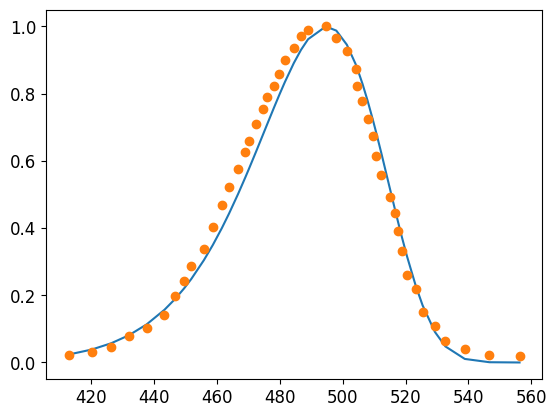

Data points: 47
Using LS starting values: E=0.988
Acceptance rate: 0.716

Metropolis-Hastings Results:
  b = 0.989 ± 0.014 (95% CI: [0.961, 1.017])
  sigma = 0.048

Fit Quality Metrics:
Metropolis: R² = 0.9801, RMSE = 0.0461


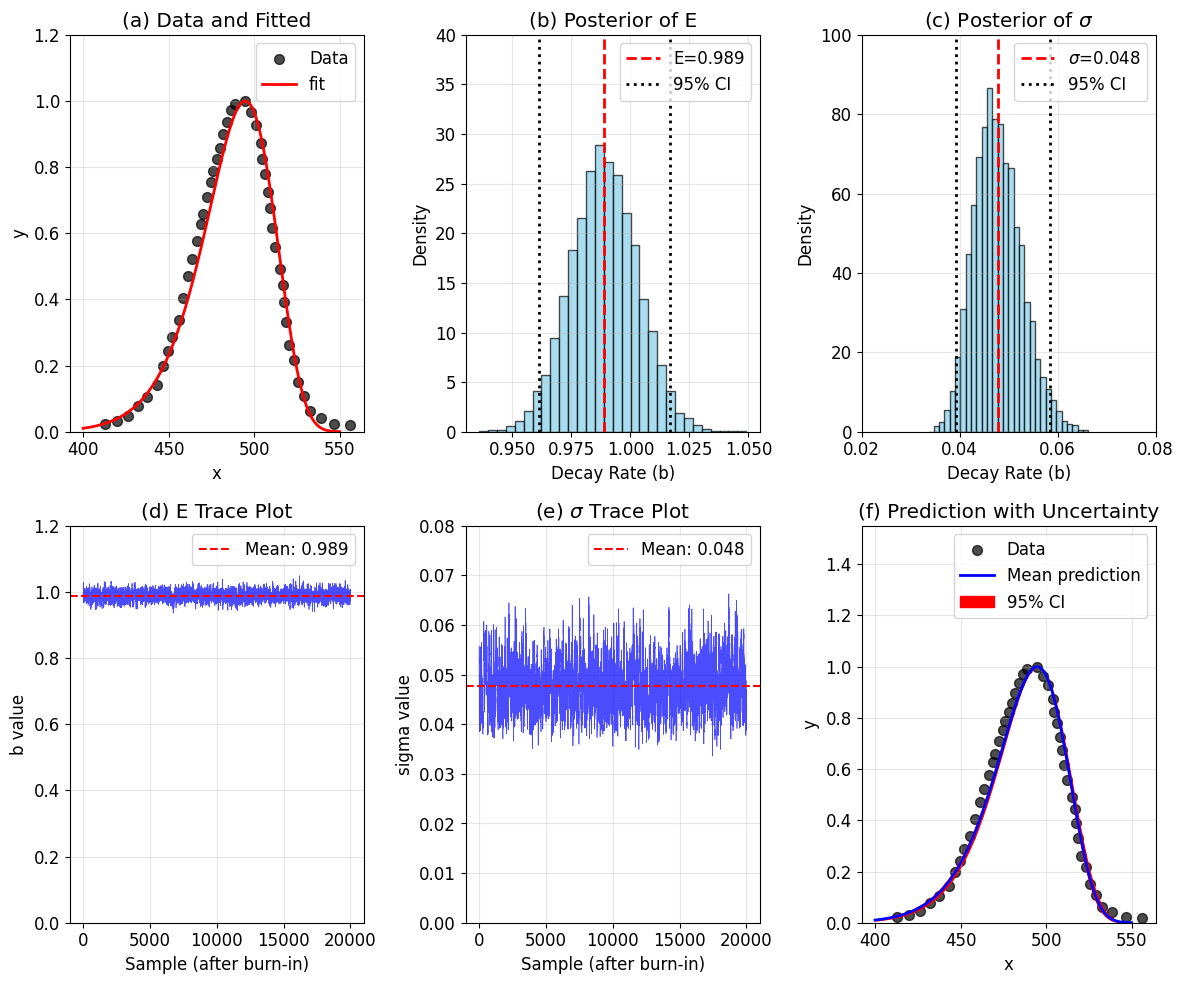


MCMC Diagnostics:
  Effective sample size: 20000
  Posterior standard deviation: 0.0142


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize
import pandas as pd
print('-'*28,'CODE OUTPUT','-'*29)
rng = np.random.default_rng(seed=122)

# --- Generate synthetic data
def readData():
    """Read TL data from GitHub."""
    url = 'https://github.com/vpagonis/Python-Codes/raw/main/Ch3PagonisGitHub/aluminaTLshort.TXT'
    df = pd.read_table(url)

    x_data = df.iloc[:, 0].to_numpy() + 273.15  # temperature in Kelvin
    y_data = df.iloc[:, 1].to_numpy()

    # Normalize
    y_data = y_data / np.max(y_data)
    Tmax = x_data[np.argmax(y_data)]

    return x_data, y_data, Tmax

# Load data
x_data, y_data, Tmax_data = readData()
kB = 8.617E-5
y_data = y_data / np.max(y_data)
Tm = x_data[np.argmax(y_data)]
Tm

def model(T,E):
    B = E/(kB*T)* (T-Tm)/Tm
    return np.exp(1+B-(T**2/Tm**2)*(1-2*kB*T/E)*np.exp(B)-2*kB*Tm/E)

t = model(x_data,1)
plt.plot(x_data,t)
plt.plot(x_data,y_data,'o')
plt.show()

def log_prior(E, sigma):
    # log prior for all parameters
    # Parameter constraints
    if E <= 0:
        return -np.inf  # Reject negative b
    if sigma <= 0:
        return -np.inf  # Reject negative sigma

    # Broad normal priors for all parameters
    log_prior_E = -0.5 * (E / 1) ** 2           # N(0, 1²)
    log_prior_sigma = -0.5 * (sigma / 10) ** 2  # HalfN(0, 10²)

    return log_prior_E + log_prior_sigma

def log_likelihood(y, y_pred, sigma):
    """Log likelihood assuming Gaussian errors"""
    return -0.5 * np.sum(((y - y_pred) / sigma) ** 2) - len(y) * np.log(sigma)

def log_posterior(params, x, y):
    """Log posterior probability"""
    E, sigma = params
    y_pred = model(x, E)
    lp = log_prior(E, sigma)
    # Check if log_prior is finite
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(y, y_pred, sigma)

def metropolis(x, y, initial_params=None, n_steps=40000, burn_in=20000):
    """Metropolis-Hastings algorithm for negative exponential fitting"""

    # Use least squares to find good starting values for b only
    # Note: curve_fit expects a function with parameters to fit
    popt, pcov = optimize.curve_fit(model, x, y, p0=[1])
    E = popt[0]
    print(f"Using LS starting values: E={E:.3f}")

    # Calculate initial sigma from residuals
    sigma = np.std(y - model(x, E))

    # Step sizes based on least squares uncertainties
    step_E = 0.01
    step_sigma = 0.05 * sigma

    current_params = np.array([E, sigma])
    current_log_post = log_posterior(current_params, x, y)

    samples = []
    acceptance_count = 0

    for i in range(n_steps):
        # Propose new parameters
        new_params = current_params + rng.normal(0, [step_E, step_sigma])

        # Check constraints before computing log_posterior
        if new_params[0] <= 0 or new_params[1] <= 0:
            # Reject automatically if constraints violated
            samples.append(current_params.copy())
            continue

        # Compute log-posterior for new parameters
        new_log_post = log_posterior(new_params, x, y)

        # Acceptance probability
        log_alpha = new_log_post - current_log_post

        if np.log(rng.random()) < log_alpha:
            current_params = new_params
            current_log_post = new_log_post
            acceptance_count += 1

        samples.append(current_params.copy())

    acceptance_rate = acceptance_count / n_steps
    print(f"Acceptance rate: {acceptance_rate:.3f}")

    # Discard burn-in and return samples
    return np.array(samples[burn_in:])


# print(f"True E value: {true_E:.3f}")
print(f"Data points: {len(x_data)}")

# Run MCMC
samples = metropolis(x_data, y_data, n_steps=40000, burn_in=20000)

# Extract parameter samples
b_samples = samples[:, 0]
sigma_samples = samples[:, 1]

# Get posterior statistics
b_est, b_std = np.mean(b_samples), np.std(b_samples)
sigma_est = np.mean(sigma_samples)

b_ci = np.percentile(b_samples, [2.5, 97.5])

sigma_ci = np.percentile(sigma_samples, [2.5, 97.5])
print("\nMetropolis-Hastings Results:")
print(f"  b = {b_est:.3f} ± {b_std:.3f} (95% CI: [{b_ci[0]:.3f}, {b_ci[1]:.3f}])")
print(f"  sigma = {sigma_est:.3f}")
# print(f"  True b = {true_E:.3f}")

# Calculate fit quality metrics
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    r_squared = 1 - np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2)
    rmse = np.sqrt(np.mean(residuals**2))
    return r_squared, rmse

# Predictions with estimated b
y_pred_mh = model(x_data, b_est)

r2_mh, rmse_mh = calculate_metrics(y_data, y_pred_mh)

print("\nFit Quality Metrics:")
print(f"Metropolis: R² = {r2_mh:.4f}, RMSE = {rmse_mh:.4f}")

# Create plots
plt.figure(figsize=(12, 10))

# Plot 1: Data and fitted model
plt.subplot(2, 3, 1)
plt.scatter(x_data, y_data, alpha=0.7, label='Data', color='black', s=50)
x_fine = np.linspace(400, 550, 200)
# plt.plot(x_fine, model(x_fine, true_b), 'g--', linewidth=2,
#          label=f'True model (b={true_b:.3f})', alpha=0.7)
plt.plot(x_fine, model(x_fine, b_est), 'r-', linewidth=2,
         label=(f'fit'))
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(0,1.2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('(a) Data and Fitted')

# Plot 2: Parameter distribution for b
plt.subplot(2, 3, 2)
plt.hist(b_samples, bins=30, alpha=0.7, density=True, edgecolor='black', color='skyblue')
plt.axvline(b_est, color='red', linestyle='--', linewidth=2, label=f'E={b_est:.3f}')
# plt.axvline(true_b, color='green', linestyle='--', linewidth=2, label=f'True: {true_b:.3f}')
plt.axvline(b_ci[0], color='black', linestyle=':', linewidth=2, label='95% CI')
plt.axvline(b_ci[1], color='black', linestyle=':', linewidth=2)
plt.xlabel('Decay Rate (b)')
plt.ylabel('Density')
plt.ylim(0,40)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('(b) Posterior of E')

# Plot 3: MCMC trace plot
plt.subplot(2, 3, 3)
plt.hist(sigma_samples, bins=30, alpha=0.7, density=True, edgecolor='black', color='skyblue')
plt.axvline(sigma_est, color='red', linestyle='--', linewidth=2, label=f'$\sigma$={sigma_est:.3f}')
# plt.axvline(true_b, color='green', linestyle='--', linewidth=2, label=f'True: {true_b:.3f}')
plt.axvline(sigma_ci[0], color='black', linestyle=':', linewidth=2, label='95% CI')
plt.axvline(sigma_ci[1], color='black', linestyle=':', linewidth=2)
plt.xlabel('Decay Rate (b)')
plt.ylabel('Density')
plt.legend()
plt.xlim(0.02,.08)
plt.ylim(0,100)
plt.grid(True, alpha=0.3)
plt.title(f'(c) Posterior of $\sigma$')

plt.subplot(2, 3, 4)
plt.plot(b_samples, alpha=0.7, linewidth=0.5, color='blue')
plt.axhline(b_est, color='red', linestyle='--', label=f'Mean: {b_est:.3f}')
# plt.axhline(true_b, color='green', linestyle='--', label=f'True: {true_b:.3f}')
plt.xlabel('Sample (after burn-in)')
plt.ylabel('b value')
plt.ylim(0,1.2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('(d) E Trace Plot')

plt.subplot(2, 3, 5)
plt.plot(sigma_samples, alpha=0.7, linewidth=0.5, color='blue')
plt.axhline(sigma_est, color='red', linestyle='--', label=f'Mean: {sigma_est:.3f}')
plt.xlabel('Sample (after burn-in)')
plt.ylabel('sigma value')
plt.ylim(0,.08)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('(e) $\sigma$ Trace Plot')

# Plot 4: Prediction with uncertainty
plt.subplot(2, 3, 6)
# Generate predictions from posterior samples
n_predict = 500
predictions = np.zeros((len(x_fine), n_predict))
random_indices = rng.integers(0, len(b_samples), n_predict)

for i, idx in enumerate(random_indices):
    b_sample = b_samples[idx]
    predictions[:, i] = model(x_fine, b_sample)

pred_mean = np.mean(predictions, axis=1)
pred_lower = np.percentile(predictions, 2.5, axis=1)
pred_upper = np.percentile(predictions, 97.5, axis=1)

plt.scatter(x_data, y_data, alpha=0.7, label='Data', color='black', s=50)
plt.plot(x_fine, pred_mean, 'b-', linewidth=2, label='Mean prediction')
plt.ylim(0,1.55)
plt.fill_between(x_fine, pred_lower, pred_upper,  color='red',
                 label='95% CI')
# plt.plot(x_fine, model(x_fine, true_b), 'g--', linewidth=1.5,
         # label='True model', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('(f) Prediction with Uncertainty')

plt.tight_layout()
plt.show()

# Print additional diagnostics
print(f"\nMCMC Diagnostics:")
print(f"  Effective sample size: {len(b_samples)}")
print(f"  Posterior standard deviation: {b_std:.4f}")


# **Figure 6 and 8 and 9**

BAYESIAN ANALYSIS FOR DOSE-RESPONSE DATA - METROPOLIS SAMPLING

Fixed parameters:
  Initial Dc: 10.00

Least squares estimates (used for prior means):
  Dc: 9.000 ± 2.000
  sigma: 0.030 ± 0.001

Running Metropolis sampler...
Evaluating chain 1
  Chain 1 acceptance rate: 0.500
Evaluating chain 2
  Chain 2 acceptance rate: 0.507
Evaluating chain 3
  Chain 3 acceptance rate: 0.517

PARAMETER SUMMARY
Parameter Mean       Std        95% HPD Lower   95% HPD Upper  
------------------------------------------------------------
Dc       9.0647     0.6180     7.9289          10.3530        
sigma    0.0386     0.0079     0.0265          0.0574         

Calculating fit statistics...

R-squared: 0.9831


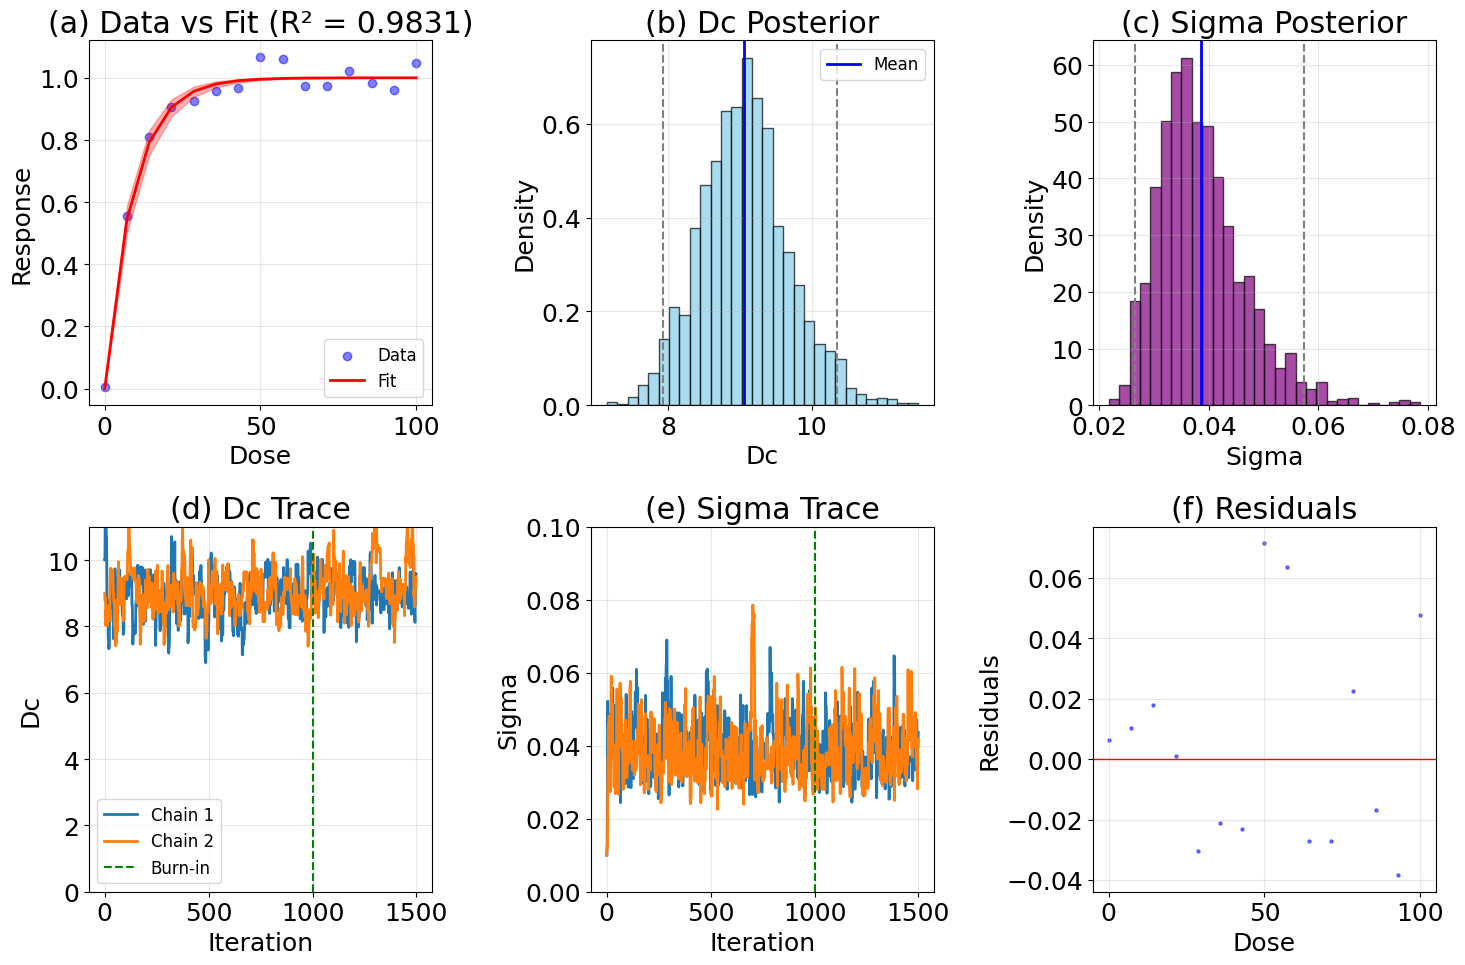


FINAL ESTIMATES
Dc: 9.0647 ± 0.6180  [95% HPD: 7.9289, 10.3530]
sigma: 0.0386 ± 0.0079  [95% HPD: 0.0265, 0.0574]

Acceptance rate: 0.508


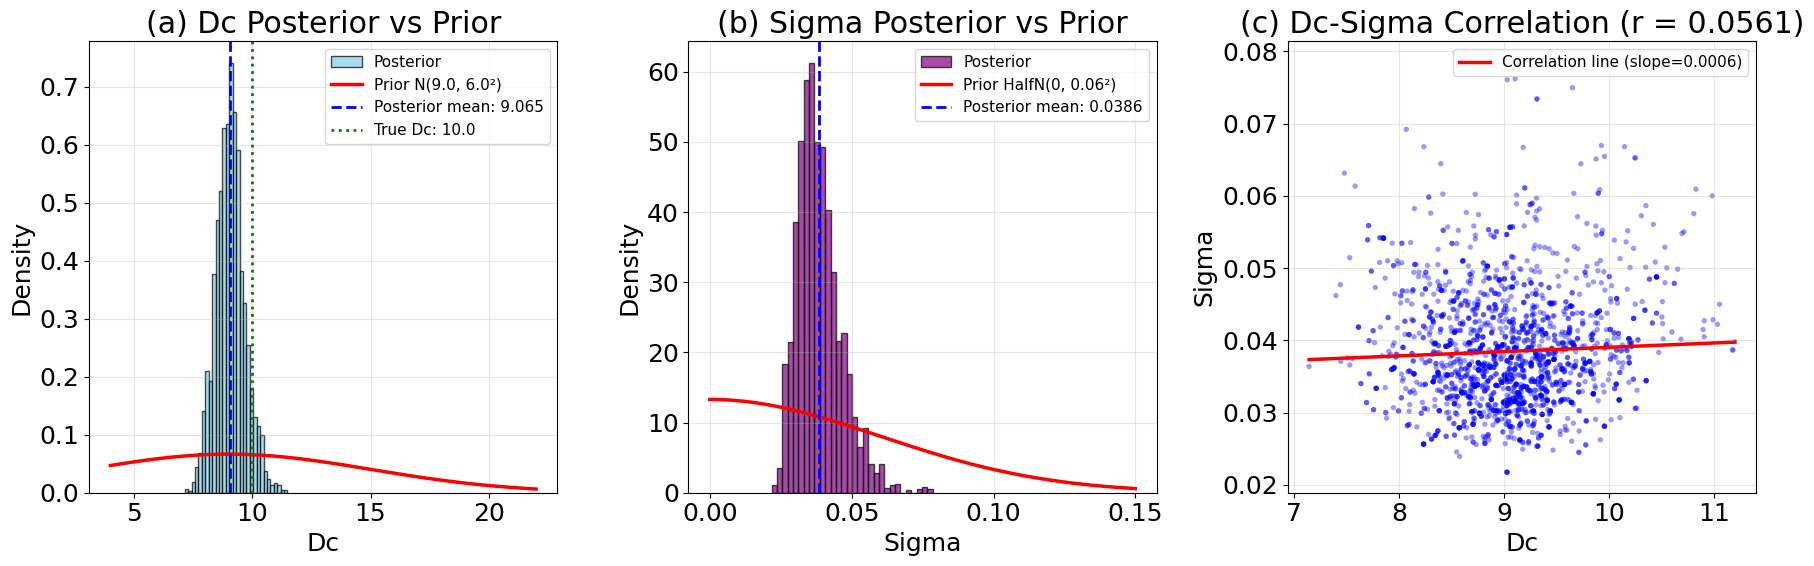


CORRELATION ANALYSIS
Dc-Sigma correlation coefficient: 0.0561
  → Weak correlation detected

Running Slice sampler...
  Average expansions per iteration: 1.99


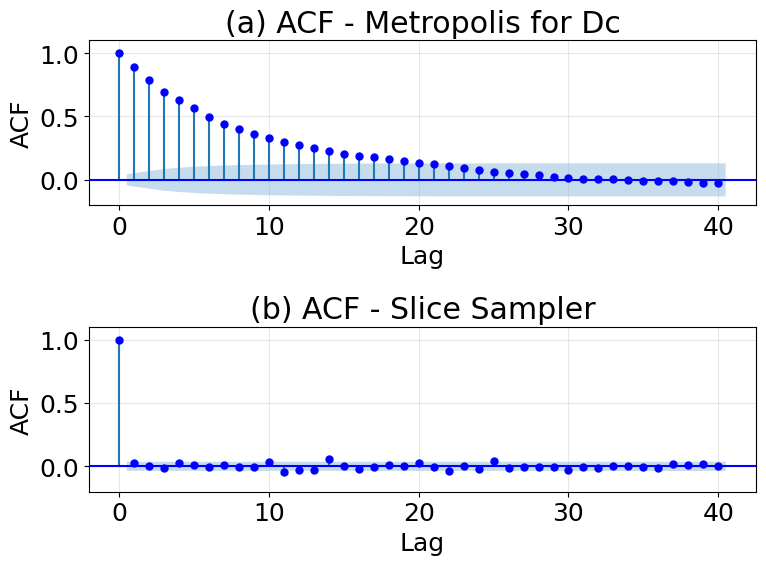


EFFECTIVE SAMPLE SIZE COMPARISON
Sampler      Parameter ESS        ESS/Iteration  
-------------------------------------------------------
Metropolis   Dc       185        0.062          
Metropolis   Sigma    319        0.106          
Slice        Dc       1223       0.408          
Slice        Sigma    1256       0.419          


In [ ]:
# <<exptal,  eval=TRUE,results='hold',echo=TRUE, fig.show='hold',collapse=TRUE,fig.align = 'center', fig.width=6,fig.height=6,  out.width='90%'>>=
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# =============================================================================
# DATA LOADING AND SETUP
# =============================================================================

np.random.seed(142)
plt.rcParams["font.size"] = 18

# Set true Dc value
true_Dc = 10.0

def readData(true_Dc):
    """Generate synthetic data with true Dc=10"""
    x_data = np.linspace(0, 100, 15)  # Match D_max = 5*Dc = 50
    y_true = 1 - np.exp(-x_data/true_Dc)
    y_data = y_true + np.random.normal(0, 0.05, len(x_data))
    return x_data, y_data

# Load data
x_data, y_data = readData(true_Dc)

# Plot data
# plt.figure()
# plt.plot(x_data, y_data, 'o', markersize=3, label='Data with noise')
# plt.plot(x_data, 1 - np.exp(-x_data/true_Dc), 'r-', label=f'True curve (Dc={true_Dc})')
# plt.xlabel('Dose')
# plt.ylabel('Response')
# plt.legend()
# plt.title('Synthetic Data')
# plt.show()

# Fixed parameters
Dc_initial = 10.0  # Characteristic dose constant

# Create dose array - MUST MATCH x_data
D = x_data  # Use same dose values as data

# Preliminary estimates (for new parameters)
LS_estimates = {'Dc': 9.0, 'sigma': 0.03}
LS_uncertainties = {'Dc': 2.0, 'sigma': 0.001}

print("="*60)
print("BAYESIAN ANALYSIS FOR DOSE-RESPONSE DATA - METROPOLIS SAMPLING")
print("="*60)
print("\nFixed parameters:")
print(f"  Initial Dc: {Dc_initial:.2f}")
# print(f"  Max Dose: {D_max:.2f}")

print("\nLeast squares estimates (used for prior means):")
print(f"  Dc: {LS_estimates['Dc']:.3f} ± {LS_uncertainties['Dc']:.3f}")
print(f"  sigma: {LS_estimates['sigma']:.3f} ± {LS_uncertainties['sigma']:.3f}")

# =============================================================================
# VECTORIZED DOSE-RESPONSE FUNCTION (NUMPY ONLY)
# =============================================================================

# Pre-compute constants for vectorized calculation
eps = 1e-10

def dose_response_numpy(Dc_val):
    """
    NumPy-based dose-response calculation using the saturating exponential equation:
    n = 1 - exp(-D/Dc)

    Dc_val is scalar value.
    D is the dose variable
    """
    # Calculate response: 1 - exp(-D/Dc)
    n = 1 - np.exp(-D/Dc_val)

    # Ensure non-negative and clip to reasonable values
    n = np.clip(n, 0, 1)

    return n

def dose_response_numpy_batch(params_batch):
    """
    Vectorized dose-response calculation for multiple parameter sets.
    params_batch: array of shape (n_samples, 2) with columns [Dc, sigma]
    Returns: array of shape (n_samples, n_points)
    """
    if params_batch.ndim == 1:
        params_batch = params_batch.reshape(1, -1)

    n_samples = params_batch.shape[0]
    result = np.zeros((n_samples, len(D)))

    for i in range(n_samples):
        result[i] = dose_response_numpy(params_batch[i, 0])

    return result

# =============================================================================
# SIMPLE METROPOLIS SAMPLER
# =============================================================================

# Prior functions - now only Dc and sigma
def log_prior(Dc_val, sigma):
    """Log prior probability."""
    if Dc_val < 5 or Dc_val > 20 or sigma <= 0:
        return -np.inf

    logp = (stats.norm.logpdf(Dc_val, LS_estimates['Dc'], LS_uncertainties['Dc']*3) +
            stats.halfnorm.logpdf(sigma, scale=LS_estimates['sigma']*2))

    return logp

def log_likelihood(Dc_val, sigma):
    """Log likelihood."""
    mu = dose_response_numpy(Dc_val)
    return np.sum(stats.norm.logpdf(y_data, mu, sigma))

def log_posterior(Dc_val, sigma):
    """Log posterior."""
    lp = log_prior(Dc_val, sigma)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(Dc_val, sigma)

def metropolis_sampler(n_iterations=10000, n_chains=3, tune=2000):
    """
    Simple Metropolis sampler.
    """
    param_names = ['Dc', 'sigma']
    n_params = 2

    # Proposal scales
    scales = np.array([0.5, 0.01])

    # Initialize chains
    samples = np.zeros((n_chains, n_iterations + tune, n_params))
    acceptance = np.zeros((n_chains, n_iterations + tune))

    print("\nRunning Metropolis sampler...")

    for chain in range(n_chains):
        print(f"Evaluating chain {chain+1}")

        # Initialize
        if chain == 0:
            current = np.array([10.0, 0.01])
        else:
            current = np.array([9.0, 0.01])

        current_logp = log_posterior(current[0], current[1])

        for i in range(n_iterations + tune):
            # Store current
            samples[chain, i] = current

            # Propose new values
            proposal = current + np.random.normal(0, scales)

            # Check bounds
            if (proposal[0] < 5 or proposal[0] > 20 or proposal[1] <= 0):
                acceptance[chain, i] = 0
                continue

            # Compute log posterior for proposal
            proposal_logp = log_posterior(proposal[0], proposal[1])

            # Metropolis acceptance
            if np.log(np.random.random()) < proposal_logp - current_logp:
                current = proposal
                current_logp = proposal_logp
                acceptance[chain, i] = 1
            else:
                acceptance[chain, i] = 0

        print(f"  Chain {chain+1} acceptance rate: {np.mean(acceptance[chain]):.3f}")

    return samples, acceptance, param_names

# Run sampler
samples, acceptance, param_names = metropolis_sampler(n_iterations=1000, n_chains=3, tune=500)

# Process samples
n_tune = 500
samples_after_burnin = samples[:, n_tune:, :]
samples_flat = samples_after_burnin.reshape(-1, 2)

# Calculate statistics
means = np.mean(samples_flat, axis=0)
stds = np.std(samples_flat, axis=0)
hpd_lower = np.percentile(samples_flat, 2.5, axis=0)
hpd_upper = np.percentile(samples_flat, 97.5, axis=0)

# Print summary
print("\n" + "="*80)
print("PARAMETER SUMMARY")
print("="*80)
print(f"{'Parameter':<8} {'Mean':<10} {'Std':<10} {'95% HPD Lower':<15} {'95% HPD Upper':<15}")
print("-"*60)
for i, name in enumerate(param_names):
    print(f"{name:<8} {means[i]:<10.4f} {stds[i]:<10.4f} {hpd_lower[i]:<15.4f} {hpd_upper[i]:<15.4f}")

# =============================================================================
# CALCULATE FIT
# =============================================================================

print("\nCalculating fit statistics...")
n_fit = min(500, len(samples_flat))
indices = np.random.choice(len(samples_flat), n_fit, replace=False)
mu_samples = dose_response_numpy_batch(samples_flat[indices])

mu_mean = np.mean(mu_samples, axis=0)
mu_hpd_lower = np.percentile(mu_samples, 2.5, axis=0)
mu_hpd_upper = np.percentile(mu_samples, 97.5, axis=0)

# Calculate R-squared
residuals = y_data - mu_mean
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"\nR-squared: {r_squared:.4f}")

# =============================================================================
# PLOTTING
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Data vs Fit
ax = axes[0, 0]
ax.scatter(D, y_data, marker='o', alpha=0.5, color='blue', label='Data')
ax.plot(D, mu_mean, 'r-', linewidth=2, label='Fit')
ax.fill_between(D, mu_hpd_lower, mu_hpd_upper, alpha=0.3, color='red')
ax.set_xlabel('Dose')
ax.set_ylabel('Response')
ax.set_title(f'(a) Data vs Fit (R² = {r_squared:.4f})')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)


# Plot 2: Dc Posterior
ax = axes[0, 1]
ax.hist(samples_flat[:, 0], bins=30, density=True, alpha=0.7,
        color='skyblue', edgecolor='black')
ax.axvline(means[0], color='blue', linewidth=2, label='Mean')
ax.axvline(hpd_lower[0], color='gray', linestyle='--')
ax.axvline(hpd_upper[0], color='gray', linestyle='--')
ax.set_xlabel('Dc')
ax.set_ylabel('Density')

ax.set_title('(b) Dc Posterior')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 3: Sigma Posterior
ax = axes[0, 2]
ax.hist(samples_flat[:, 1], bins=30, density=True, alpha=0.7,
        color='purple', edgecolor='black')
ax.axvline(means[1], color='blue', linewidth=2)
ax.axvline(hpd_lower[1], color='gray', linestyle='--')
ax.axvline(hpd_upper[1], color='gray', linestyle='--')
ax.set_xlabel('Sigma')
ax.set_ylabel('Density')
ax.set_title('(c) Sigma Posterior')
ax.grid(True, alpha=0.3)

# Plot 4: Dc Trace
ax = axes[1, 0]
for chain in range(2):
    ax.plot(samples[chain, :, 0], linewidth=2, label=f'Chain {chain+1}')
ax.axvline(1000, color='green', linestyle='--', label='Burn-in')
ax.set_xlabel('Iteration')
ax.set_ylabel('Dc')
ax.set_title('(d) Dc Trace')
ax.legend(fontsize=12)
ax.set_ylim(0,11)
ax.grid(True, alpha=0.3)

# Plot 5: Sigma Trace
ax = axes[1, 1]
for chain in range(2):
    ax.plot(samples[chain, :, 1],  linewidth=2)
ax.axvline(1000, color='green', linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('Sigma')
ax.set_title('(e) Sigma Trace')
ax.set_ylim(0,.1)
ax.grid(True, alpha=0.3)

# Plot 6: Residuals
ax = axes[1, 2]
ax.scatter(D, residuals, s=5, alpha=0.5, color='blue')
ax.axhline(0, color='red', linewidth=1)
ax.set_xlabel('Dose')
ax.set_ylabel('Residuals')
ax.set_title('(f) Residuals')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "="*60)
print("FINAL ESTIMATES")
print("="*60)
for i, name in enumerate(param_names):
    print(f"{name}: {means[i]:.4f} ± {stds[i]:.4f}  [95% HPD: {hpd_lower[i]:.4f}, {hpd_upper[i]:.4f}]")

print(f"\nAcceptance rate: {np.mean(acceptance):.3f}")

# Save results
results_df = pd.DataFrame({
    'Parameter': param_names,
    'Mean': means,
    'Std': stds,
    'HDI_2.5%': hpd_lower,
    'HDI_97.5%': hpd_upper
})

# =============================================================================
# ADDITIONAL DIAGNOSTIC PLOTS
# =============================================================================

# @

# =============================================================================
# THREE-PANEL PLOT: POSTERIORS WITH PRIORS + CORRELATION
# =============================================================================

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 6))

plt.rcParams["font.size"] = 18
# Panel 1: Dc posterior with prior PDF
ax = axes3[0]
# Posterior histogram
ax.hist(samples_flat[:, 0], bins=30, density=True, alpha=0.7,
        color='skyblue', edgecolor='black', label='Posterior')
# Prior PDF for Dc: N(LS_estimates['Dc'], LS_uncertainties['Dc']*3)
x_dc = np.linspace(4, 22, 1000)
prior_dc = stats.norm.pdf(x_dc, LS_estimates['Dc'], LS_uncertainties['Dc']*3)
ax.plot(x_dc, prior_dc, 'r-', linewidth=2.5, label='Prior N(9.0, 6.0²)')
ax.axvline(means[0], color='blue', linestyle='--', linewidth=2, label=f'Posterior mean: {means[0]:.3f}')
ax.axvline(true_Dc, color='green', linestyle=':', linewidth=2, label=f'True Dc: {true_Dc}')
ax.set_xlabel('Dc')
ax.set_ylabel('Density')
ax.set_title('(a) Dc Posterior vs Prior')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Panel 2: Sigma posterior with prior PDF
ax = axes3[1]
# Posterior histogram
ax.hist(samples_flat[:, 1], bins=30, density=True, alpha=0.7,
        color='purple', edgecolor='black', label='Posterior')
# Prior PDF for sigma: HalfNormal(scale=LS_estimates['sigma']*2)
x_sigma = np.linspace(0, 0.15, 1000)
prior_sigma = stats.halfnorm.pdf(x_sigma, scale=LS_estimates['sigma']*2)
ax.plot(x_sigma, prior_sigma, 'r-', linewidth=2.5, label='Prior HalfN(0, 0.06²)')
ax.axvline(means[1], color='blue', linestyle='--', linewidth=2, label=f'Posterior mean: {means[1]:.4f}')
ax.set_xlabel('Sigma')
ax.set_ylabel('Density')
ax.set_title('(b) Sigma Posterior vs Prior')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Panel 3: Dc-Sigma correlation plot
# Panel 3: Dc-Sigma correlation plot (without colormap)
ax = axes3[2]
# Sample a subset for cleaner visualization (2000 points)
sample_idx = np.random.choice(len(samples_flat), size=2000, replace=False)
dc_subset = samples_flat[sample_idx, 0]
sigma_subset = samples_flat[sample_idx, 1]

# Simple scatter plot without colormap
ax.scatter(dc_subset, sigma_subset, alpha=0.4, s=15, color='blue', edgecolors='none')

# Add correlation line
z = np.polyfit(dc_subset, sigma_subset, 1)
p = np.poly1d(z)
ax.plot(np.sort(dc_subset), p(np.sort(dc_subset)), 'r-',
        linewidth=2.5, label=f'Correlation line (slope={z[0]:.4f})')

# Calculate and display correlation coefficient
corr_coef = np.corrcoef(samples_flat[:, 0], samples_flat[:, 1])[0, 1]
ax.set_xlabel('Dc')
ax.set_ylabel('Sigma')
ax.set_title(f'(c) Dc-Sigma Correlation (r = {corr_coef:.4f})')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# plt.suptitle('Posterior Analysis with Priors and Correlation', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Print correlation information
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)
print(f"Dc-Sigma correlation coefficient: {corr_coef:.4f}")
if abs(corr_coef) > 0.5:
    print("  → Strong correlation detected")
elif abs(corr_coef) > 0.3:
    print("  → Moderate correlation detected")
else:
    print("  → Weak correlation detected")

# =============================================================================
# SLICE SAMPLER IMPLEMENTATION
# =============================================================================

def slice_sampler(n_samples=3000, tune=1000, x_init=None, w=1.0):
    """
    Simple slice sampler for Dc and sigma.
    """
    if x_init is None:
        x_init = np.array([10.0, 0.03])

    n_total = n_samples + tune
    samples = np.zeros((n_total, 2))
    current = x_init.copy()

    # Track acceptance for diagnostics (slice sampler typically has high acceptance)
    n_expansions = 0

    print("\nRunning Slice sampler...")

    for i in range(n_total):
        # Store current sample
        samples[i] = current

        # Sample each parameter in turn (coordinate-wise slice sampling)
        for param_idx in range(2):
            # Current log posterior at current position
            log_p_current = log_posterior(current[0], current[1])

            # Sample u ~ Uniform(0, exp(log_p_current)) in unnormalized space
            log_u = log_p_current + np.log(np.random.random())

            # Define the slice: {theta: log_posterior(theta) > log_u}
            # Initialize bracket around current value
            if param_idx == 0:  # Dc
                # Initial bracket width
                x_l = current[0] - w * np.random.random()
                x_r = x_l + w

                # Expand bracket until both ends are outside the slice
                # Check left side
                while True:
                    log_p_l = log_posterior(x_l, current[1])
                    if log_p_l > log_u:
                        x_l -= w
                        n_expansions += 1
                    else:
                        break

                # Check right side
                while True:
                    log_p_r = log_posterior(x_r, current[1])
                    if log_p_r > log_u:
                        x_r += w
                        n_expansions += 1
                    else:
                        break

                # Sample from within the bracket (shrinkage sampling)
                while True:
                    x_prop = x_l + np.random.random() * (x_r - x_l)
                    log_p_prop = log_posterior(x_prop, current[1])

                    if log_p_prop > log_u:
                        current[0] = x_prop
                        break
                    elif x_prop < current[0]:
                        x_l = x_prop
                    else:
                        x_r = x_prop

            else:  # Sigma
                # Initial bracket width
                x_l = max(0.001, current[1] - w * np.random.random())
                x_r = x_l + w

                # Expand bracket until both ends are outside the slice
                # Check left side
                while True:
                    if x_l <= 0.001:
                        break
                    log_p_l = log_posterior(current[0], x_l)
                    if log_p_l > log_u:
                        x_l = max(0.001, x_l - w)
                        n_expansions += 1
                    else:
                        break

                # Check right side
                while True:
                    log_p_r = log_posterior(current[0], x_r)
                    if log_p_r > log_u:
                        x_r += w
                        n_expansions += 1
                    else:
                        break

                # Sample from within the bracket (shrinkage sampling)
                while True:
                    x_prop = x_l + np.random.random() * (x_r - x_l)
                    log_p_prop = log_posterior(current[0], x_prop)

                    if log_p_prop > log_u:
                        current[1] = x_prop
                        break
                    elif x_prop < current[1]:
                        x_l = x_prop
                    else:
                        x_r = x_prop

    print(f"  Average expansions per iteration: {n_expansions/n_total:.2f}")
    return samples[tune:]

# Run slice sampler
samples_slice = slice_sampler(n_samples=3000, tune=1000)
samples_slice_dc = samples_slice[:, 0]
samples_slice_sigma = samples_slice[:, 1]

# =============================================================================
# TWO-PANEL ACF COMPARISON PLOT
# =============================================================================

from statsmodels.graphics.tsaplots import plot_acf

fig4, axes4 = plt.subplots(2, 1, figsize=(8,6))
plt.rcParams["font.size"] = 18

# Panel 1: ACF for Dc - Metropolis
ax = axes4[0]
plot_acf(samples_flat[:2000, 0], lags=40, ax=ax, alpha=0.05, color='blue')
ax.set_title('(a) ACF - Metropolis for Dc')
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, 1.1)

# # Panel 2: ACF for Sigma - Metropolis
# ax = axes4[0, 1]
# plot_acf(samples_flat[:2000, 1], lags=40, ax=ax, alpha=0.05, color='purple')
# ax.set_title('(b) Sigma ACF - Metropolis')
# ax.set_xlabel('Lag')
# ax.set_ylabel('Autocorrelation')
# ax.grid(True, alpha=0.3)
# ax.set_ylim(-0.2, 1.1)

# Panel 3: ACF for Dc - Slice
ax = axes4[1]
plot_acf(samples_slice_dc, lags=40, ax=ax, alpha=0.05, color='blue')
ax.set_title('(b) ACF - Slice Sampler')
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, 1.1)

# # Panel 4: ACF for Sigma - Slice
# ax = axes4[1, 1]
# plot_acf(samples_slice_sigma, lags=40, ax=ax, alpha=0.05, color='purple')
# ax.set_title('(d) Sigma ACF - Slice Sampler')
# ax.set_xlabel('Lag')
# ax.set_ylabel('Autocorrelation')
# ax.grid(True, alpha=0.3)
# ax.set_ylim(-0.2, 1.1)

# plt.suptitle('Autocorrelation Function Comparison: Metropolis vs Slice Sampler', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# EFFECTIVE SAMPLE SIZE COMPARISON
# =============================================================================

def effective_sample_size(samples, max_lag=100):
    """Calculate effective sample size using autocorrelation."""
    n = len(samples)

    # Compute autocorrelation
    acf = np.correlate(samples - np.mean(samples), samples - np.mean(samples), mode='full')
    acf = acf[len(acf)//2:] / acf[len(acf)//2]

    # Find first lag where acf becomes negative or crosses zero
    rho = acf[1:max_lag+1]
    rho_positive = rho[rho > 0]

    if len(rho_positive) > 0:
        ess = n / (1 + 2 * np.sum(rho_positive))
    else:
        ess = n

    return ess

# Calculate ESS for Metropolis
ess_dc_metropolis = effective_sample_size(samples_flat[:, 0])
ess_sigma_metropolis = effective_sample_size(samples_flat[:, 1])

# Calculate ESS for Slice
ess_dc_slice = effective_sample_size(samples_slice_dc)
ess_sigma_slice = effective_sample_size(samples_slice_sigma)

print("\n" + "="*60)
print("EFFECTIVE SAMPLE SIZE COMPARISON")
print("="*60)
print(f"{'Sampler':<12} {'Parameter':<8} {'ESS':<10} {'ESS/Iteration':<15}")
print("-"*55)
print(f"{'Metropolis':<12} {'Dc':<8} {ess_dc_metropolis:<10.0f} {ess_dc_metropolis/len(samples_flat):<15.3f}")
print(f"{'Metropolis':<12} {'Sigma':<8} {ess_sigma_metropolis:<10.0f} {ess_sigma_metropolis/len(samples_flat):<15.3f}")
print(f"{'Slice':<12} {'Dc':<8} {ess_dc_slice:<10.0f} {ess_dc_slice/len(samples_slice_dc):<15.3f}")
print(f"{'Slice':<12} {'Sigma':<8} {ess_sigma_slice:<10.0f} {ess_sigma_slice/len(samples_slice_sigma):<15.3f}")

# **Figure 7**

VECTORIZED BAYESIAN ANALYSIS FOR DOSE-RESPONSE DATA

RUNNING VECTORIZED ANALYSIS

--- Testing with n = 5 data points ---
  Replicate 1/2
  Replicate 2/2
  Results: Dc = 7.5015 ± 1.2416
           sigma = 0.0285 ± 0.0081
           acceptance = 0.977

--- Testing with n = 10 data points ---
  Replicate 1/2
  Replicate 2/2
  Results: Dc = 7.8670 ± 1.3016
           sigma = 0.0535 ± 0.0116
           acceptance = 0.976

--- Testing with n = 15 data points ---
  Replicate 1/2
  Replicate 2/2
  Results: Dc = 8.7141 ± 0.6387
           sigma = 0.0390 ± 0.0088
           acceptance = 0.961

--- Testing with n = 20 data points ---
  Replicate 1/2
  Replicate 2/2
  Results: Dc = 9.9764 ± 0.6921
           sigma = 0.0491 ± 0.0083
           acceptance = 0.964

--- Testing with n = 25 data points ---
  Replicate 1/2
  Replicate 2/2
  Results: Dc = 10.4145 ± 0.7345
           sigma = 0.0548 ± 0.0082
           acceptance = 0.965

--- Testing with n = 30 data points ---
  Replicate 1/2
  Replicate 

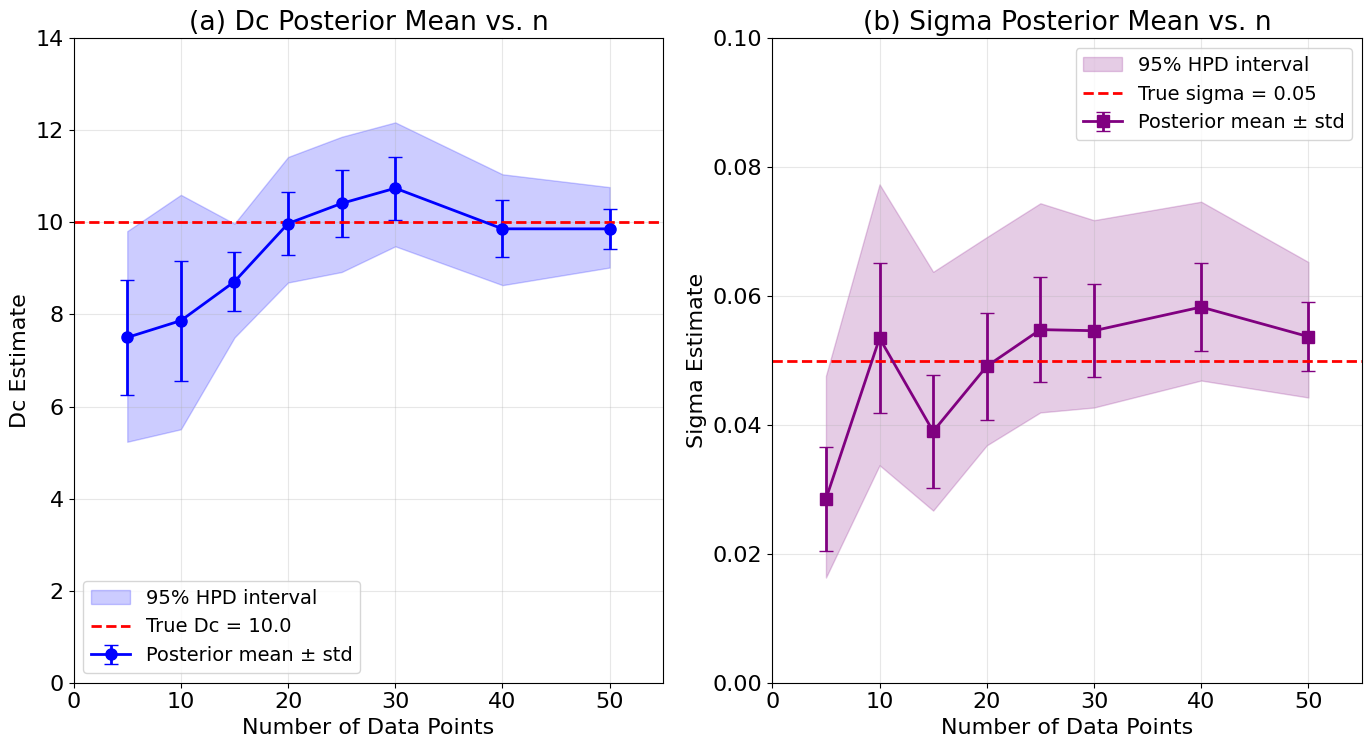


SUMMARY: Effect of Number of Data Points on Posterior Means
n_points   Dc_mean      Dc_std       Dc_95%_lower    Dc_95%_upper    sigma_mean   sigma_std    Accept% 
-----------------------------------------------------------------------------------------------
5          7.5015       1.2416       5.2353          9.8101          0.0285       0.0081       97.7    
10         7.8670       1.3016       5.5065          10.5996         0.0535       0.0116       97.6    
15         8.7141       0.6387       7.5001          9.9735          0.0390       0.0088       96.1    
20         9.9764       0.6921       8.6952          11.4219         0.0491       0.0083       96.4    
25         10.4145      0.7345       8.9233          11.8606         0.0548       0.0082       96.5    
30         10.7440      0.6877       9.4813          12.1736         0.0546       0.0072       96.2    
40         9.8613       0.6223       8.6377          11.0457         0.0583       0.0069       95.8    
50         

In [ ]:
# <<exptal,  eval=TRUE,results='hold',echo=TRUE, fig.show='hold',collapse=TRUE,fig.align = 'center', fig.width=12,fig.height=14,  out.width='90%'>>=
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# DATA LOADING AND SETUP
# =============================================================================

np.random.seed(142)

# Set true values
true_Dc = 10.0
true_sigma = 0.05

def readData(true_Dc, n_points):
    """Generate synthetic data with true Dc=10 and specified number of points"""
    x_data = np.linspace(0, 100, n_points)  # Fixed dose range 0-100
    y_true = 1 - np.exp(-x_data/true_Dc)
    y_data = y_true + np.random.normal(0, true_sigma, len(x_data))
    return x_data, y_data

# Fixed parameters
Dc_initial = 10.0  # Characteristic dose constant

# Preliminary estimates (for priors)
LS_estimates = {'Dc': 9.0, 'sigma': 0.03}
LS_uncertainties = {'Dc': 2.0, 'sigma': 0.001}

print("="*60)
print("VECTORIZED BAYESIAN ANALYSIS FOR DOSE-RESPONSE DATA")
print("="*60)

# =============================================================================
# VECTORIZED DOSE-RESPONSE FUNCTION
# =============================================================================

def dose_response_vectorized(Dc_vals, D):
    """
    Fully vectorized dose-response calculation.
    Dc_vals: array of shape (n_samples,) or scalar
    D: array of shape (n_points,)
    Returns: array of shape (n_samples, n_points)
    """
    Dc_vals = np.asarray(Dc_vals)
    # Handle scalar input
    if Dc_vals.ndim == 0:
        return 1 - np.exp(-D / Dc_vals)
    # Vectorized calculation for multiple Dc values
    # Reshape for broadcasting: (n_samples, 1) @ (1, n_points) -> (n_samples, n_points)
    Dc_col = Dc_vals.reshape(-1, 1)
    D_row = D.reshape(1, -1)
    result = 1 - np.exp(-D_row / Dc_col)
    return np.clip(result, 0, 1)

# =============================================================================
# VECTORIZED LIKELIHOOD AND PRIOR FUNCTIONS
# =============================================================================

def log_likelihood_vectorized(Dc_vals, sigma_vals, y_data, D):
    """
    Vectorized log likelihood for multiple parameter sets.
    Dc_vals: array of shape (n_samples,)
    sigma_vals: array of shape (n_samples,)
    Returns: array of shape (n_samples,)
    """
    mu = dose_response_vectorized(Dc_vals, D)  # Shape: (n_samples, n_points)
    # Vectorized normal logpdf calculation
    residuals = y_data - mu
    # Sum over data points for each sample
    return -0.5 * np.sum((residuals / sigma_vals[:, np.newaxis])**2, axis=1) - len(y_data) * np.log(sigma_vals)

def log_prior_vectorized(Dc_vals, sigma_vals, LS_estimates, LS_uncertainties):
    """
    Fully vectorized log prior for multiple parameter sets.
    Returns: array of shape (n_samples,)
    """
    # Create masks for invalid parameters
    invalid_mask = (Dc_vals < 5) | (Dc_vals > 20) | (sigma_vals <= 0)

    # Initialize log prior with -inf for invalid parameters
    logp = np.full_like(Dc_vals, -np.inf, dtype=float)

    # Calculate log prior for valid parameters
    valid_mask = ~invalid_mask
    if np.any(valid_mask):
        Dc_valid = Dc_vals[valid_mask]
        sigma_valid = sigma_vals[valid_mask]

        logp_valid = (stats.norm.logpdf(Dc_valid, LS_estimates['Dc'], LS_uncertainties['Dc']*3) +
                      stats.halfnorm.logpdf(sigma_valid, scale=LS_estimates['sigma']*2))
        logp[valid_mask] = logp_valid

    return logp

def log_posterior_vectorized(Dc_vals, sigma_vals, y_data, D, LS_estimates, LS_uncertainties):
    """
    Vectorized log posterior for multiple parameter sets.
    """
    logp = log_prior_vectorized(Dc_vals, sigma_vals, LS_estimates, LS_uncertainties)
    # Only calculate likelihood for valid parameters
    valid_mask = np.isfinite(logp)

    if np.any(valid_mask):
        logl = log_likelihood_vectorized(Dc_vals[valid_mask], sigma_vals[valid_mask], y_data, D)
        logp[valid_mask] += logl

    return logp

# =============================================================================
# VECTORIZED METROPOLIS SAMPLER (Multiple chains in parallel)
# =============================================================================

def metropolis_sampler_vectorized(D, y_data, n_iterations=20000, n_chains=4, tune=10000):
    """
    Vectorized Metropolis sampler with multiple chains running in parallel.
    """
    n_params = 2
    total_iterations = n_iterations + tune

    # Proposal scales
    scales = np.array([0.05, 0.0005])

    # Initialize chains in parallel with different starting points
    current = np.zeros((n_chains, n_params))
    current[:, 0] = np.random.uniform(8, 12, n_chains)  # Dc
    current[:, 1] = np.random.uniform(0.01, 0.08, n_chains)  # sigma

    # Storage for samples
    samples = np.zeros((n_chains, total_iterations, n_params))
    acceptance = np.zeros((n_chains, total_iterations))

    # Compute initial log posteriors in parallel
    current_logp = log_posterior_vectorized(
        current[:, 0], current[:, 1], y_data, D, LS_estimates, LS_uncertainties
    )

    for i in range(total_iterations):
        # Store current samples
        samples[:, i, :] = current

        # Generate proposals for all chains in parallel
        proposals = current + np.random.normal(0, scales, size=(n_chains, n_params))

        # Compute log posteriors for all proposals in parallel
        proposal_logp = log_posterior_vectorized(
            proposals[:, 0], proposals[:, 1], y_data, D, LS_estimates, LS_uncertainties
        )

        # Metropolis acceptance (vectorized)
        log_alpha = proposal_logp - current_logp
        log_u = np.log(np.random.random(n_chains))
        accept = log_u < log_alpha

        # Update accepted chains
        current[accept] = proposals[accept]
        current_logp[accept] = proposal_logp[accept]
        acceptance[:, i] = accept

    return samples, acceptance

# =============================================================================
# VECTORIZED ANALYSIS FOR MULTIPLE N_POINTS
# =============================================================================

def analyze_multiple_n_points_vectorized(n_points_list, n_replicates=2):
    """
    Run analysis for multiple n_points values, possibly with replicates.
    """
    results = []

    for n_points in n_points_list:
        print(f"\n--- Testing with n = {n_points} data points ---")

        # Generate data
        D, y_data = readData(true_Dc, n_points)

        # Run multiple replicates
        replicate_results = []

        for rep in range(n_replicates):
            print(f"  Replicate {rep+1}/{n_replicates}")

            samples, acceptance = metropolis_sampler_vectorized(
                D, y_data, n_iterations=15000, n_chains=4, tune=8000
            )

            # Process samples (burn-in)
            n_tune = 8000
            samples_after_burnin = samples[:, n_tune:, :]
            samples_flat = samples_after_burnin.reshape(-1, 2)

            # Calculate statistics efficiently
            means = np.mean(samples_flat, axis=0)
            stds = np.std(samples_flat, axis=0)
            hpd_lower = np.percentile(samples_flat, 2.5, axis=0)
            hpd_upper = np.percentile(samples_flat, 97.5, axis=0)

            replicate_results.append({
                'Dc_mean': means[0],
                'Dc_std': stds[0],
                'Dc_hpd_lower': hpd_lower[0],
                'Dc_hpd_upper': hpd_upper[0],
                'sigma_mean': means[1],
                'sigma_std': stds[1],
                'sigma_hpd_lower': hpd_lower[1],
                'sigma_hpd_upper': hpd_upper[1],
                'acceptance_rate': np.mean(acceptance)
            })

        # Average over replicates
        avg_result = {
            'n_points': n_points,
            'Dc_mean': np.mean([r['Dc_mean'] for r in replicate_results]),
            'Dc_std': np.mean([r['Dc_std'] for r in replicate_results]),
            'Dc_hpd_lower': np.mean([r['Dc_hpd_lower'] for r in replicate_results]),
            'Dc_hpd_upper': np.mean([r['Dc_hpd_upper'] for r in replicate_results]),
            'sigma_mean': np.mean([r['sigma_mean'] for r in replicate_results]),
            'sigma_std': np.mean([r['sigma_std'] for r in replicate_results]),
            'sigma_hpd_lower': np.mean([r['sigma_hpd_lower'] for r in replicate_results]),
            'sigma_hpd_upper': np.mean([r['sigma_hpd_upper'] for r in replicate_results]),
            'acceptance_rate': np.mean([r['acceptance_rate'] for r in replicate_results])
        }

        results.append(avg_result)
        print(f"  Results: Dc = {avg_result['Dc_mean']:.4f} ± {avg_result['Dc_std']:.4f}")
        print(f"           sigma = {avg_result['sigma_mean']:.4f} ± {avg_result['sigma_std']:.4f}")
        print(f"           acceptance = {avg_result['acceptance_rate']:.3f}")

    return pd.DataFrame(results)

# =============================================================================
# PERFORMANCE COMPARISON
# =============================================================================

def compare_performance():
    """Compare performance of original vs vectorized code."""

    n_points = 20
    D, y_data = readData(true_Dc, n_points)

    # Original (sequential) version - recreated for comparison
    def metropolis_sampler_original(D, y_data, n_iterations=15000, n_chains=2, tune=8000):
        n_params = 2
        scales = np.array([0.05, 0.0005])
        total_iterations = n_iterations + tune

        samples = np.zeros((n_chains, total_iterations, n_params))
        acceptance = np.zeros((n_chains, total_iterations))

        for chain in range(n_chains):
            if chain == 0:
                current = np.array([10.0, 0.01])
            else:
                current = np.array([9.0, 0.01])

            current_logp = log_posterior_vectorized(
                np.array([current[0]]), np.array([current[1]]), y_data, D,
                LS_estimates, LS_uncertainties
            )[0]

            for i in range(total_iterations):
                samples[chain, i] = current
                proposal = current + np.random.normal(0, scales)

                if proposal[0] < 5 or proposal[0] > 20 or proposal[1] <= 0:
                    acceptance[chain, i] = 0
                    continue

                proposal_logp = log_posterior_vectorized(
                    np.array([proposal[0]]), np.array([proposal[1]]), y_data, D,
                    LS_estimates, LS_uncertainties
                )[0]

                if np.log(np.random.random()) < proposal_logp - current_logp:
                    current = proposal
                    current_logp = proposal_logp
                    acceptance[chain, i] = 1
                else:
                    acceptance[chain, i] = 0

        return samples, acceptance

    # Time original version
    start_time = time.time()
    samples_orig, acceptance_orig = metropolis_sampler_original(
        D, y_data, n_iterations=15000, n_chains=2, tune=8000
    )
    orig_time = time.time() - start_time

    # Time vectorized version
    start_time = time.time()
    samples_vec, acceptance_vec = metropolis_sampler_vectorized(
        D, y_data, n_iterations=15000, n_chains=4, tune=8000
    )
    vec_time = time.time() - start_time

    print("\n" + "="*60)
    print("PERFORMANCE COMPARISON")
    print("="*60)
    print(f"Original (2 chains): {orig_time:.2f} seconds")
    print(f"Vectorized (4 chains): {vec_time:.2f} seconds")
    print(f"Speedup factor (samples per second): {(4*15000/vec_time)/(2*15000/orig_time):.2f}x")

    return orig_time, vec_time

# =============================================================================
# MAIN ANALYSIS
# =============================================================================

# Define n_points list
n_points_list = [5, 10, 15, 20, 25, 30, 40, 50]

# Run vectorized analysis
print("\n" + "="*60)
print("RUNNING VECTORIZED ANALYSIS")
print("="*60)
results_df = analyze_multiple_n_points_vectorized(n_points_list, n_replicates=2)

# Run performance comparison
orig_time, vec_time = compare_performance()

# =============================================================================
# CALCULATE RELATIVE ERRORS
# =============================================================================

results_df['Dc_rel_error'] = np.abs(results_df['Dc_mean'] - true_Dc) / true_Dc * 100
results_df['sigma_rel_error'] = np.abs(results_df['sigma_mean'] - true_sigma) / true_sigma * 100

# =============================================================================
# PLOTTING - ALL PLOTS IN ONE FIGURE
# =============================================================================

fig = plt.figure(figsize=(14, 8))

plt.rcParams["font.size"] = 16
# Plot 1: Dc mean vs n_points
ax1 = plt.subplot(1,2, 1)
ax1.errorbar(results_df['n_points'], results_df['Dc_mean'],
            yerr=results_df['Dc_std'], fmt='o-', capsize=5,
            color='blue', markersize=8, linewidth=2, label='Posterior mean ± std')
ax1.fill_between(results_df['n_points'],
                results_df['Dc_hpd_lower'],
                results_df['Dc_hpd_upper'],
                alpha=0.2, color='blue', label='95% HPD interval')
ax1.axhline(y=true_Dc, color='red', linestyle='--', linewidth=2,
           label=f'True Dc = {true_Dc}')
ax1.set_xlabel('Number of Data Points')
ax1.set_ylabel('Dc Estimate')
ax1.set_title('(a) Dc Posterior Mean vs. n')
ax1.legend(fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 55)
ax1.set_ylim(0, 14)

# Plot 2: Sigma mean vs n_points
ax2 = plt.subplot(1,2, 2)
ax2.errorbar(results_df['n_points'], results_df['sigma_mean'],
            yerr=results_df['sigma_std'], fmt='s-', capsize=5,
            color='purple', markersize=8, linewidth=2, label='Posterior mean ± std')
ax2.fill_between(results_df['n_points'],
                results_df['sigma_hpd_lower'],
                results_df['sigma_hpd_upper'],
                alpha=0.2, color='purple', label='95% HPD interval')
ax2.axhline(y=true_sigma, color='red', linestyle='--', linewidth=2,
           label=f'True sigma = {true_sigma}')
ax2.set_xlabel('Number of Data Points')
ax2.set_ylabel('Sigma Estimate')
ax2.set_title('(b) Sigma Posterior Mean vs. n')
ax2.legend(fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 55)
ax2.set_ylim(0, .1)
# # Plot 3: Dc uncertainty reduction
# ax3 = plt.subplot(2, 2, 3)
# ax3.plot(results_df['n_points'], results_df['Dc_std'], 'o-',
#         color='blue', markersize=8, linewidth=2)
# ax3.set_xlabel('Number of Data Points')
# ax3.set_ylabel('Standard Deviation of Dc')
# ax3.set_title('(c) Dc Uncertainty Reduction')
# ax3.grid(True, alpha=0.3)
# ax3.set_xlim(0, 55)

# # Plot 4: Sigma uncertainty reduction
# ax4 = plt.subplot(2, 2, 4)
# ax4.plot(results_df['n_points'], results_df['sigma_std'], 's-',
#         color='purple', markersize=8, linewidth=2)
# ax4.set_xlabel('Number of Data Points')
# ax4.set_ylabel('Standard Deviation of Sigma')
# ax4.set_title('(d) Sigma Uncertainty Reduction')
# ax4.grid(True, alpha=0.3)
# ax4.set_xlim(0, 55)


# plt.suptitle('Effect of Sample Size on Parameter Estimation',
#              fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# =============================================================================
# PRINT SUMMARY TABLES
# =============================================================================

print("\n" + "="*80)
print("SUMMARY: Effect of Number of Data Points on Posterior Means")
print("="*80)
print(f"{'n_points':<10} {'Dc_mean':<12} {'Dc_std':<12} {'Dc_95%_lower':<15} {'Dc_95%_upper':<15} "
      f"{'sigma_mean':<12} {'sigma_std':<12} {'Accept%':<8}")
print("-"*95)

for _, row in results_df.iterrows():
    print(f"{int(row['n_points']):<10} {row['Dc_mean']:<12.4f} {row['Dc_std']:<12.4f} "
          f"{row['Dc_hpd_lower']:<15.4f} {row['Dc_hpd_upper']:<15.4f} "
          f"{row['sigma_mean']:<12.4f} {row['sigma_std']:<12.4f} "
          f"{row['acceptance_rate']*100:<8.1f}")

print("\n" + "="*80)
print("RELATIVE ERRORS SUMMARY")
print("="*80)
print(f"{'n_points':<10} {'Dc Rel Error (%)':<20} {'Sigma Rel Error (%)':<20}")
print("-"*50)

for _, row in results_df.iterrows():
    print(f"{int(row['n_points']):<10} {row['Dc_rel_error']:<20.2f} {row['sigma_rel_error']:<20.2f}")

# =============================================================================
# FIND MINIMUM SAMPLE SIZE FOR ERROR THRESHOLDS
# =============================================================================

print("\n" + "="*60)
print("SAMPLE SIZE FOR ERROR THRESHOLDS")
print("="*60)

# Dc thresholds
dc_thresholds = [5, 2, 1]
print("\nDc (true value = 10):")
for thresh in dc_thresholds:
    n_required = results_df[results_df['Dc_rel_error'] <= thresh]['n_points'].min()
    if pd.notna(n_required):
        print(f"  {thresh}% error: n ≥ {int(n_required)}")
    else:
        print(f"  {thresh}% error: Not achieved with up to n={int(results_df['n_points'].max())}")

# Sigma thresholds
sigma_thresholds = [20, 10, 5]
print("\nSigma (true value = 0.05):")
for thresh in sigma_thresholds:
    n_required = results_df[results_df['sigma_rel_error'] <= thresh]['n_points'].min()
    if pd.notna(n_required):
        print(f"  {thresh}% error: n ≥ {int(n_required)}")
    else:
        print(f"  {thresh}% error: Not achieved with up to n={int(results_df['n_points'].max())}")

print("\n" + "="*60)
print("VECTORIZED BAYESIAN ANALYSIS COMPLETE")
print("="*60)
